# Proyek Analisis Data: [Bike sharing]
- **Nama:** [Nayyara farhana Nisa]
- **Email:** [nayyafn2006@gmail.com]
- **ID Dicoding:** [CDCC001D6X2429]

## Menentukan Pertanyaan Bisnis

### Pertanyaan 1
Selama periode 2011-2012, bagaimana perubahan rata-rata peminjaman sepeda per bulan serta perbedaannya menurut musim dan kondisi cuaca untuk menentukan periode prioritas penambahan kapasitas operasional?

### Pertanyaan 2
Selama periode 2011-2012, kapan jam puncak peminjaman pada hari kerja dan akhir pekan, serta bagaimana perbedaan pola pengguna casual dan registered untuk menyusun strategi redistribusi sepeda dan promosi yang lebih tepat waktu?

Keterangan:

1. Tren jumlah penyewaan sepeda harian berdasarkan bulan dan musim

Specific: Fokus pada "tren jumlah penyewaan sepeda harian" berdasarkan dua variabel utama yaitu "bulan" dan "musim" dalam satu tahun terakhir. Tidak sekadar melihat total penyewaan secara umum, tetapi diarahkan pada pola waktu yang lebih spesifik.

Measurable: Data yang digunakan berupa jumlah penyewaan sepeda harian (count), sehingga dapat diukur secara kuantitatif dan divisualisasikan dengan line chart

Action-Oriented: Hasil analisis dapat digunakan untuk menentukan strategi operasional, seperti penambahan armada pada musim dengan permintaan tinggi atau promosi pada periode rendah.

Relevant: Analisis tren ini penting untuk memahami pola permintaan pengguna, yang berkaitan langsung dengan efisiensi operasional dan peningkatan pendapatan layanan bike sharing.

Time-bound: Dibatasi pada periode "1 tahun terakhir", sehingga analisis memiliki konteks waktu yang jelas dan relevan terhadap kondisi terbaru.


2. Waktu puncak penyewaan dan perbedaan hari kerja vs akhir pekan

Specific: Fokus pada "waktu puncak penyewaan sepeda" serta "perbandingan jumlah penyewaan antara hari kerja dan akhir pekan". Tidak hanya melihat jumlah total, tetapi juga distribusi berdasarkan kategori waktu dan jenis hari.

Measurable: Puncak penyewaan dapat diukur dari nilai maksimum jumlah penyewaan (count), serta dibandingkan secara kuantitatif antara dua kategori (working day vs weekend).

Action-Oriented: Insight dari analisis ini dapat digunakan untuk pengaturan jadwal operasional, alokasi sepeda, serta penentuan strategi tarif atau promosi yang berbeda antara hari kerja dan akhir pekan.

Relevant: Mengetahui pola puncak dan perbedaan perilaku pengguna sangat penting untuk meningkatkan efisiensi layanan dan kepuasan pengguna.

Time-bound: Analisis dilakukan dalam periode dataset yang sama, yaitu "1 tahun terakhir", sehingga hasilnya konsisten dan dapat dibandingkan secara langsung.

- **Pertanyaan 1:** xxx
- **Pertanyaan 2:** xxx
- ...

## Import Semua Packages/Library yang Digunakan

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import warnings

warnings.filterwarnings('ignore')
alt.data_transformers.disable_max_rows()

COLOR_PRIMARY = '#2E86AB'
COLOR_SECONDARY = '#A23B72'
COLOR_ACCENT = '#F18F01'
COLOR_NEUTRAL = '#C73E1D'
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL]

## Data Wrangling

### Gathering Data

#### Load df day and hour

In [4]:
#Memuat tabel day.csv menjadi data frame
day_df = pd.read_csv("day.csv")
day_df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
#Memuat tabel hour.csv menjadi dataframe
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

#### Identifying day_df problem

In [4]:
# Menampilkan informasi data day_df
day_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Steps to Take:**
- mengubah tipe data dteday
- mengubah data season, whethersit,mnth,weekday,working day dan holiday menjadi kategori

**Insight:**
- Tidak terdapat missing value
- kolom dteday bukan tipe object tapi datetime
* data season, whethersit,mnth,weekday,working day dan holiday merupakan data kategori hasil label encoding
* Jumlah data sebanyak 731




In [5]:
#Identifikasi missing value day_df
day_df.isna().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
tidak terdapat missing value

In [6]:
#Identifikasi data duplikat day_df
print("jumlah duplikasi: ", day_df.duplicated().sum())
#ringkasan parameter statistik day_df
day_df.describe()

jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**step to take:**
1. menangani innacurate value (hum)


**insight:**
1. tidak terdapat data duplikasi
2. standar deviasi beberapa fitur terlalu besar mengindikasikan variais data terlalu besar
3. nilai kelembaban (hum) tidak mungkin 0%

In [10]:
def summarize_all_outliers(dataframe):
    numeric_columns = dataframe.select_dtypes(include=['number']).columns

    rows = []
    for column in numeric_columns:
        q1 = dataframe[column].quantile(0.25)
        q3 = dataframe[column].quantile(0.75)
        iqr_value = q3 - q1
        lower_bound = q1 - 1.5 * iqr_value
        upper_bound = q3 + 1.5 * iqr_value

        outlier_mask = (dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)
        outlier_count = outlier_mask.sum()
        outlier_percentage = (outlier_count / len(dataframe)) * 100

        rows.append({
            'column': column,
            'outlier_count': int(outlier_count),
            'outlier_percentage': round(outlier_percentage, 2),
            'lower_bound': round(lower_bound, 3),
            'upper_bound': round(upper_bound, 3)
        })

    return pd.DataFrame(rows).sort_values(
        by='outlier_count',
        ascending=False
    )



In [11]:
display(summarize_all_outliers(day_df))


,column,outlier_count,outlier_percentage,lower_bound,upper_bound
12,casual,44,6.02,-855.250,2266.750
4,holiday,21,2.87,0.000,0.000
11,windspeed,13,1.78,-0.012,0.381
10,hum,2,0.27,0.205,1.046
2,yr,0,0.00,-1.500,2.500
1,season,0,0.00,0.500,4.500
0,instant,0,0.00,-364.000,1096.000
6,workingday,0,0.00,-1.500,2.500
5,weekday,0,0.00,-5.000,11.000
3,mnth,0,0.00,-5.000,19.000


**step to take**
Outlier tidak dihapus karena merepresentasikan kondisi nyata, seperti lonjakan penggunaan sepeda pada hari libur atau akhir pekan, sehingga tetap memberikan insight penting dalam analisis.

**insight:**
df_day
casual: terdapat 44 outlier (6.02%) yang menunjukkan lonjakan pengguna casual. Data dipertahankan karena relevan dengan pola permintaan.
holiday: terdapat 21 outlier (2.87%) karena variabel bersifat biner dan nilai 1 jarang muncul. Data tidak dianggap error.
windspeed: terdapat 13 outlier (1.78%) yang menunjukkan angin relatif tinggi. Data dipertahankan karena masih valid secara cuaca.
hum: terdapat 2 outlier (0.27%) yang menunjukkan kelembapan ekstrem. Data dipertahankan karena jumlahnya kecil dan masih masuk akal.


### Identifying hour_df problem

In [9]:
display(summarize_all_outliers(hour_df))

,column,outlier_count,outlier_percentage,lower_bound,upper_bound
13,casual,1192,6.86,-62.000,114.000
14,registered,680,3.91,-245.000,499.000
15,cnt,505,2.91,-321.500,642.500
5,holiday,500,2.88,0.000,0.000
12,windspeed,342,1.97,-0.119,0.478
11,hum,22,0.13,0.030,1.230
8,weathersit,3,0.02,-0.500,3.500
0,instant,0,0.00,-8688.000,26068.000
7,workingday,0,0.00,-1.500,2.500
6,weekday,0,0.00,-5.000,11.000


**step to take:**
Outlier tidak dihapus karena merepresentasikan kondisi nyata, sehingga tetap memberikan insight penting dalam analisis.

**insight**

df_hour
casual: terdapat 1192 outlier (6.86%) yang menunjukkan lonjakan pengguna casual per jam. Data dipertahankan karena penting untuk analisis demand.
registered: terdapat 680 outlier (3.91%) yang menunjukkan lonjakan pengguna registered, terutama pada jam sibuk.
cnt: terdapat 505 outlier (2.91%) yang menunjukkan puncak total peminjaman.
holiday: terdapat 500 outlier (2.88%) karena nilai hari libur relatif jarang.
windspeed: terdapat 342 outlier (1.97%) yang menunjukkan angin relatif tinggi.
hum: terdapat 22 outlier (0.13%) yang menunjukkan kelembapan ekstrem.
weathersit: terdapat 3 outlier (0.02%) karena kategori cuaca buruk sangat jarang muncul.

In [8]:
# Menampilkan informasi data hour_df
hour_df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**step to take**
mengubah tipe data dteday

**Insight**
tipe data dteday bukan object tapi datetime

In [9]:
#Identifikasi missing value hour_df
hour_df.isna().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**insight:**
tidak terdapat missing value

In [10]:
#Identifikasi data duplikat hour_df
print("jumlah duplikasi: ", hour_df.duplicated().sum())
#ringkasan parameter statistik hour_df
hour_df.describe()

jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
1. tidak terdapat data duplikat
2. tidak terdapat inaccurate value
3. standar deviasi beberapa fitur >1 mengindikasikan variasi data tinggi
4. Data berjumlah 17379 data


### Cleaning Data

In [16]:
CHART_WIDTH = 700
CHART_HEIGHT = 360
MONTH_ORDER = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
WEEKDAY_ORDER = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
HEATMAP_WEEKDAY_ORDER = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
SEASON_ORDER = ['Spring', 'Summer', 'Fall', 'Winter']
WEATHER_ORDER = ['Clear', 'Mist', 'Light Rain/Snow', 'Heavy Rain/Snow']

In [12]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
year_map = {0: '2011', 1: '2012'}

#### Fixing day_df problem


In [15]:
df_day_clean = day_df.copy()
df_hour_clean = hour_df.copy()

for dataset in [df_day_clean, df_hour_clean]:
    dataset['dteday'] = pd.to_datetime(dataset['dteday'])

In [17]:
for dataset in [df_day_clean, df_hour_clean]:
    dataset['season_label'] = pd.Categorical(
        dataset['season'].map(season_map), categories=SEASON_ORDER, ordered=True
    )
    dataset['weather_label'] = pd.Categorical(
        dataset['weathersit'].map(weather_map), categories=WEATHER_ORDER, ordered=True
    )
    dataset['weekday_label'] = pd.Categorical(
        dataset['weekday'].map(weekday_map), categories=WEEKDAY_ORDER, ordered=True
    )
    dataset['year_label'] = dataset['yr'].map(year_map)
    dataset['month_name'] = pd.Categorical(
        dataset['dteday'].dt.strftime('%b'), categories=MONTH_ORDER, ordered=True
    )
    dataset['day_type'] = np.where(dataset['workingday'].eq(1), 'Working Day', 'Weekend/Holiday')

In [18]:
MAX_TEMP_C = 41
MAX_ATEMP_C = 50
MAX_HUMIDITY = 100
MAX_WINDSPEED = 67

for dataset in [df_day_clean, df_hour_clean]:
    dataset['temp_celsius'] = (dataset['temp'] * MAX_TEMP_C).round(2)
    dataset['atemp_celsius'] = (dataset['atemp'] * MAX_ATEMP_C).round(2)
    dataset['humidity_pct'] = (dataset['hum'] * MAX_HUMIDITY).round(2)
    dataset['windspeed_kmh'] = (dataset['windspeed'] * MAX_WINDSPEED).round(2)

In [19]:
df_day_clean['demand_tier'] = pd.qcut(
    df_day_clean['cnt'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

df_hour_clean['demand_period'] = pd.cut(
    df_hour_clean['hr'],
    bins=[-1, 5, 11, 15, 19, 23],
    labels=['Late Night', 'Morning Commute', 'Midday', 'Evening Commute', 'Night']
)

In [20]:
validation_summary = pd.DataFrame({
    'check': [
        'dteday converted to datetime',
        'season_label available in df_day_clean',
        'weather_label available in df_hour_clean',
        'cnt consistency preserved in df_day_clean',
        'cnt consistency preserved in df_hour_clean'
    ],
    'result': [
        pd.api.types.is_datetime64_any_dtype(df_day_clean['dteday']) and pd.api.types.is_datetime64_any_dtype(df_hour_clean['dteday']),
        df_day_clean['season_label'].notna().all(),
        df_hour_clean['weather_label'].notna().all(),
        bool((df_day_clean['cnt'] == df_day_clean['casual'] + df_day_clean['registered']).all()),
        bool((df_hour_clean['cnt'] == df_hour_clean['casual'] + df_hour_clean['registered']).all())
    ]
})

display(validation_summary)
df_day_clean[['dteday', 'season_label', 'weather_label', 'temp_celsius', 'humidity_pct', 'day_type', 'demand_tier']].head()

,check,result
0,dteday converted to datetime,True
1,season_label available in df_day_clean,True
2,weather_label available in df_hour_clean,True
3,cnt consistency preserved in df_day_clean,True
4,cnt consistency preserved in df_hour_clean,True


,dteday,season_label,weather_label,temp_celsius,humidity_pct,day_type,demand_tier
0,2011-01-01,Spring,Mist,14.11,80.58,Weekend/Holiday,Low
1,2011-01-02,Spring,Mist,14.90,69.61,Weekend/Holiday,Low
2,2011-01-03,Spring,Clear,8.05,43.73,Working Day,Low
3,2011-01-04,Spring,Clear,8.20,59.04,Working Day,Low
4,2011-01-05,Spring,Clear,9.31,43.70,Working Day,Low


In [13]:
#Menampilkan inaccurate value
day_df[day_df.hum == day_df.hum.min()].copy() #menampilkan inaccurate value sebelum interpolasi


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
68,69,2011-03-10,1,0,3,0,4,1,3,0.389091,0.385668,0.0,0.261877,46,577,623


In [14]:
#Menangani inaccurate value kolom hum pada day_df
day_df['hum'] = day_df['hum'].replace(0, np.nan) #Mengubah 0 menjadi NaN
day_df.hum.interpolate(method='linear', limit_direction='forward') #interpolasi data

,hum
0,0.805833
1,0.696087
2,0.437273
3,0.590435
4,0.436957
...,...
726,0.652917
727,0.590000
728,0.752917
729,0.483333


In [15]:
#menampilkan data sesudah interpolasi
day_df[day_df.hum == day_df.hum.min()]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
49,50,2011-02-19,1,0,2,0,6,0,1,0.399167,0.391404,0.187917,0.507463,532,1103,1635


**Insight:**
kolom hum yang memiliki nilai 0% dilakukan interpolasi karena jika data dihapus akan memengaruhi proses EDA
inaccurate value sudah diubah sesuai dengan titik hitung berdasarkan range data yang telah ada

### fixing hour_df problem

In [16]:
#Mengubah tipe data dteday
datetime_columns = ["dteday"]

for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

hour_df['dteday'].head() #Menampilkan data dteday setelah mengubah tipe data

,dteday
0,2011-01-01
1,2011-01-01
2,2011-01-01
3,2011-01-01
4,2011-01-01


In [17]:
#Menampilkan inaccurate value
hour_df[hour_df['hum'] == 0].copy() # sebelum interpolasi


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1551,1552,2011-03-10,1,0,3,0,0,4,1,3,0.34,0.3182,0.0,0.2537,3,0,3
1552,1553,2011-03-10,1,0,3,1,0,4,1,3,0.34,0.3182,0.0,0.2537,0,2,2
1553,1554,2011-03-10,1,0,3,2,0,4,1,3,0.34,0.3182,0.0,0.2537,0,1,1
1554,1555,2011-03-10,1,0,3,5,0,4,1,3,0.36,0.3485,0.0,0.1940,1,2,3
1555,1556,2011-03-10,1,0,3,6,0,4,1,3,0.36,0.3333,0.0,0.3284,0,12,12
1556,1557,2011-03-10,1,0,3,7,0,4,1,3,0.38,0.3939,0.0,0.2239,1,36,37
1557,1558,2011-03-10,1,0,3,8,0,4,1,3,0.38,0.3939,0.0,0.2836,1,43,44
1558,1559,2011-03-10,1,0,3,9,0,4,1,3,0.40,0.4091,0.0,0.2239,1,23,24
1559,1560,2011-03-10,1,0,3,10,0,4,1,3,0.40,0.4091,0.0,0.1642,0,17,17
1560,1561,2011-03-10,1,0,3,11,0,4,1,3,0.40,0.4091,0.0,0.2537,6,5,11


In [18]:
#mengubah tipe data dteday
hour_df['hum'] = hour_df['hum'].replace(0, np.nan) #Mengubah 0 menjadi NaN

hour_df['hum'] = (
    hour_df['hum']
    .interpolate(method='linear', limit_direction='both') #interpolasi data
    .bfill()
    .ffill()
)
hour_df[['dteday', 'hr', 'hum']].loc[1553:1573]

,dteday,hr,hum
1553,2011-03-10,2,0.939130
1554,2011-03-10,5,0.942174
1555,2011-03-10,6,0.945217
1556,2011-03-10,7,0.948261
1557,2011-03-10,8,0.951304
1558,2011-03-10,9,0.954348
1559,2011-03-10,10,0.957391
1560,2011-03-10,11,0.960435
1561,2011-03-10,12,0.963478
1562,2011-03-10,13,0.966522


## Exploratory Data Analysis (EDA)

### Explore day_df

In [21]:
monthly_trend = (
    df_day_clean.groupby(['year_label', 'month_name'], observed=False)['cnt']
    .mean()
    .dropna()
    .reset_index(name='average_rentals')
    .sort_values(['year_label', 'month_name'])
)

monthly_trend

,year_label,month_name,average_rentals
0,2011,Jan,1231.903226
1,2011,Feb,1721.964286
2,2011,Mar,2065.967742
3,2011,Apr,3162.333333
4,2011,May,4381.322581
5,2011,Jun,4783.733333
6,2011,Jul,4559.387097
7,2011,Aug,4409.387097
8,2011,Sep,4247.266667
9,2011,Oct,3984.225806


In [22]:
seasonal_avg = (
    df_day_clean.groupby('season_label', observed=False)['cnt']
    .mean()
    .dropna()
    .reset_index(name='average_rentals')
    .sort_values('average_rentals', ascending=False)
)

seasonal_avg

,season_label,average_rentals
2,Fall,5644.303191
1,Summer,4992.331522
3,Winter,4728.162921
0,Spring,2604.132597


In [23]:
weather_avg = (
    df_day_clean.groupby('weather_label', observed=False)['cnt']
    .mean()
    .dropna()
    .reset_index(name='average_rentals')
    .sort_values('average_rentals', ascending=False)
)

weather_avg

,weather_label,average_rentals
0,Clear,4876.786177
1,Mist,4035.862348
2,Light Rain/Snow,1803.285714


In [24]:
day_type_summary = (
    df_day_clean.groupby('day_type')[['cnt', 'casual', 'registered']]
    .mean()
    .round(2)
)
day_type_summary['registered_share_pct'] = (
    day_type_summary['registered'] / day_type_summary['cnt'] * 100
).round(2)

day_type_summary

,cnt,casual,registered,registered_share_pct
day_type,,,,
Weekend/Holiday,4330.17,1371.13,2959.03,68.34
Working Day,4584.82,606.57,3978.25,86.77


In [25]:
hourly_day_type = (
    df_hour_clean.pivot_table(
        index='hr',
        columns='day_type',
        values='cnt',
        aggfunc='mean'
    )
    .round(2)
)

hourly_day_type

day_type,Weekend/Holiday,Working Day
hr,,
0,90.80,36.79
1,69.51,16.55
2,53.17,8.68
3,25.78,4.94
4,8.26,5.43
5,8.69,24.91
6,18.74,102.50
7,43.41,290.61
8,105.65,477.01


In [26]:
hourly_rider_profile = (
    df_hour_clean.groupby('hr')[['casual', 'registered']]
    .mean()
    .round(2)
)
hourly_rider_profile['registered_to_casual_ratio'] = (
    hourly_rider_profile['registered'] / hourly_rider_profile['casual']
).round(2)

hourly_rider_profile

,casual,registered,registered_to_casual_ratio
hr,,,
0,10.16,43.74,4.31
1,6.50,26.87,4.13
2,4.77,18.10,3.79
3,2.72,9.01,3.31
4,1.25,5.10,4.08
5,1.41,18.48,13.11
6,4.16,71.88,17.28
7,11.06,201.01,18.17
8,21.68,337.33,15.56


In [27]:
correlation_matrix = df_day_clean[
    ['temp_celsius', 'atemp_celsius', 'humidity_pct', 'windspeed_kmh', 'casual', 'registered', 'cnt']
].corr().round(3)

correlation_matrix

,temp_celsius,atemp_celsius,humidity_pct,windspeed_kmh,casual,registered,cnt
temp_celsius,1.000,0.992,0.127,-0.158,0.543,0.540,0.627
atemp_celsius,0.992,1.000,0.140,-0.184,0.544,0.544,0.631
humidity_pct,0.127,0.140,1.000,-0.249,-0.077,-0.091,-0.101
windspeed_kmh,-0.158,-0.184,-0.249,1.000,-0.168,-0.217,-0.235
casual,0.543,0.544,-0.077,-0.168,1.000,0.395,0.673
registered,0.540,0.544,-0.091,-0.217,0.395,1.000,0.946
cnt,0.627,0.631,-0.101,-0.235,0.673,0.946,1.000


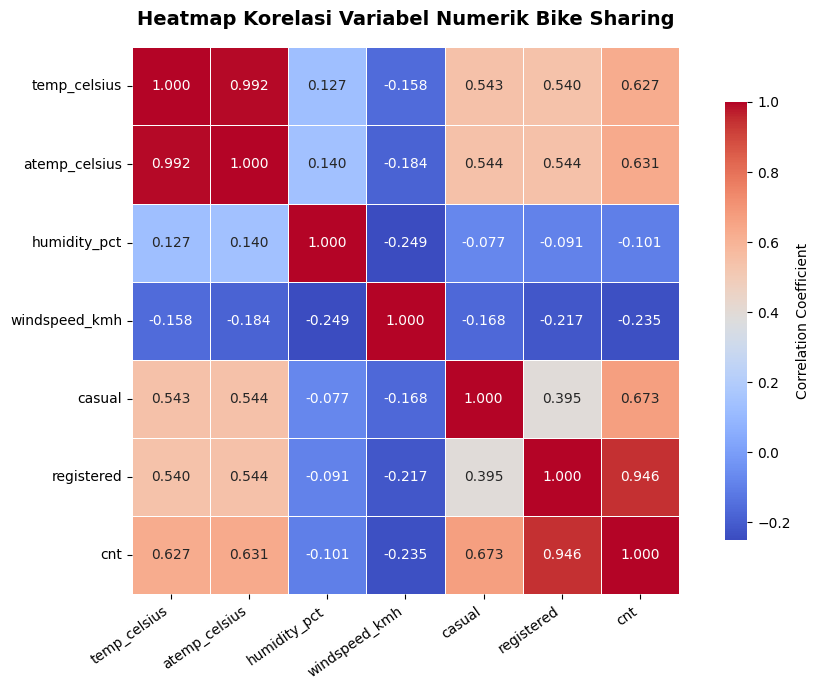

In [28]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.6,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title('Heatmap Korelasi Variabel Numerik Bike Sharing', fontsize=14, fontweight='bold', pad=16)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**insight:**
Berdasarkan heatmap tersebut, terdapat korelasi tertinggi antar variable yaitu variabel registered dengan cnt yang menunjukkan bahwa banyaknya pengguna yang melakukan peminjaman member berpengaruh terhadap total pengguna, begitupun sebaliknya. Selain itu, suhu aktual yang diukur juga berpengaruh terhadap suhu yang dirasakan oleh manusia begitupun sebaliknya.

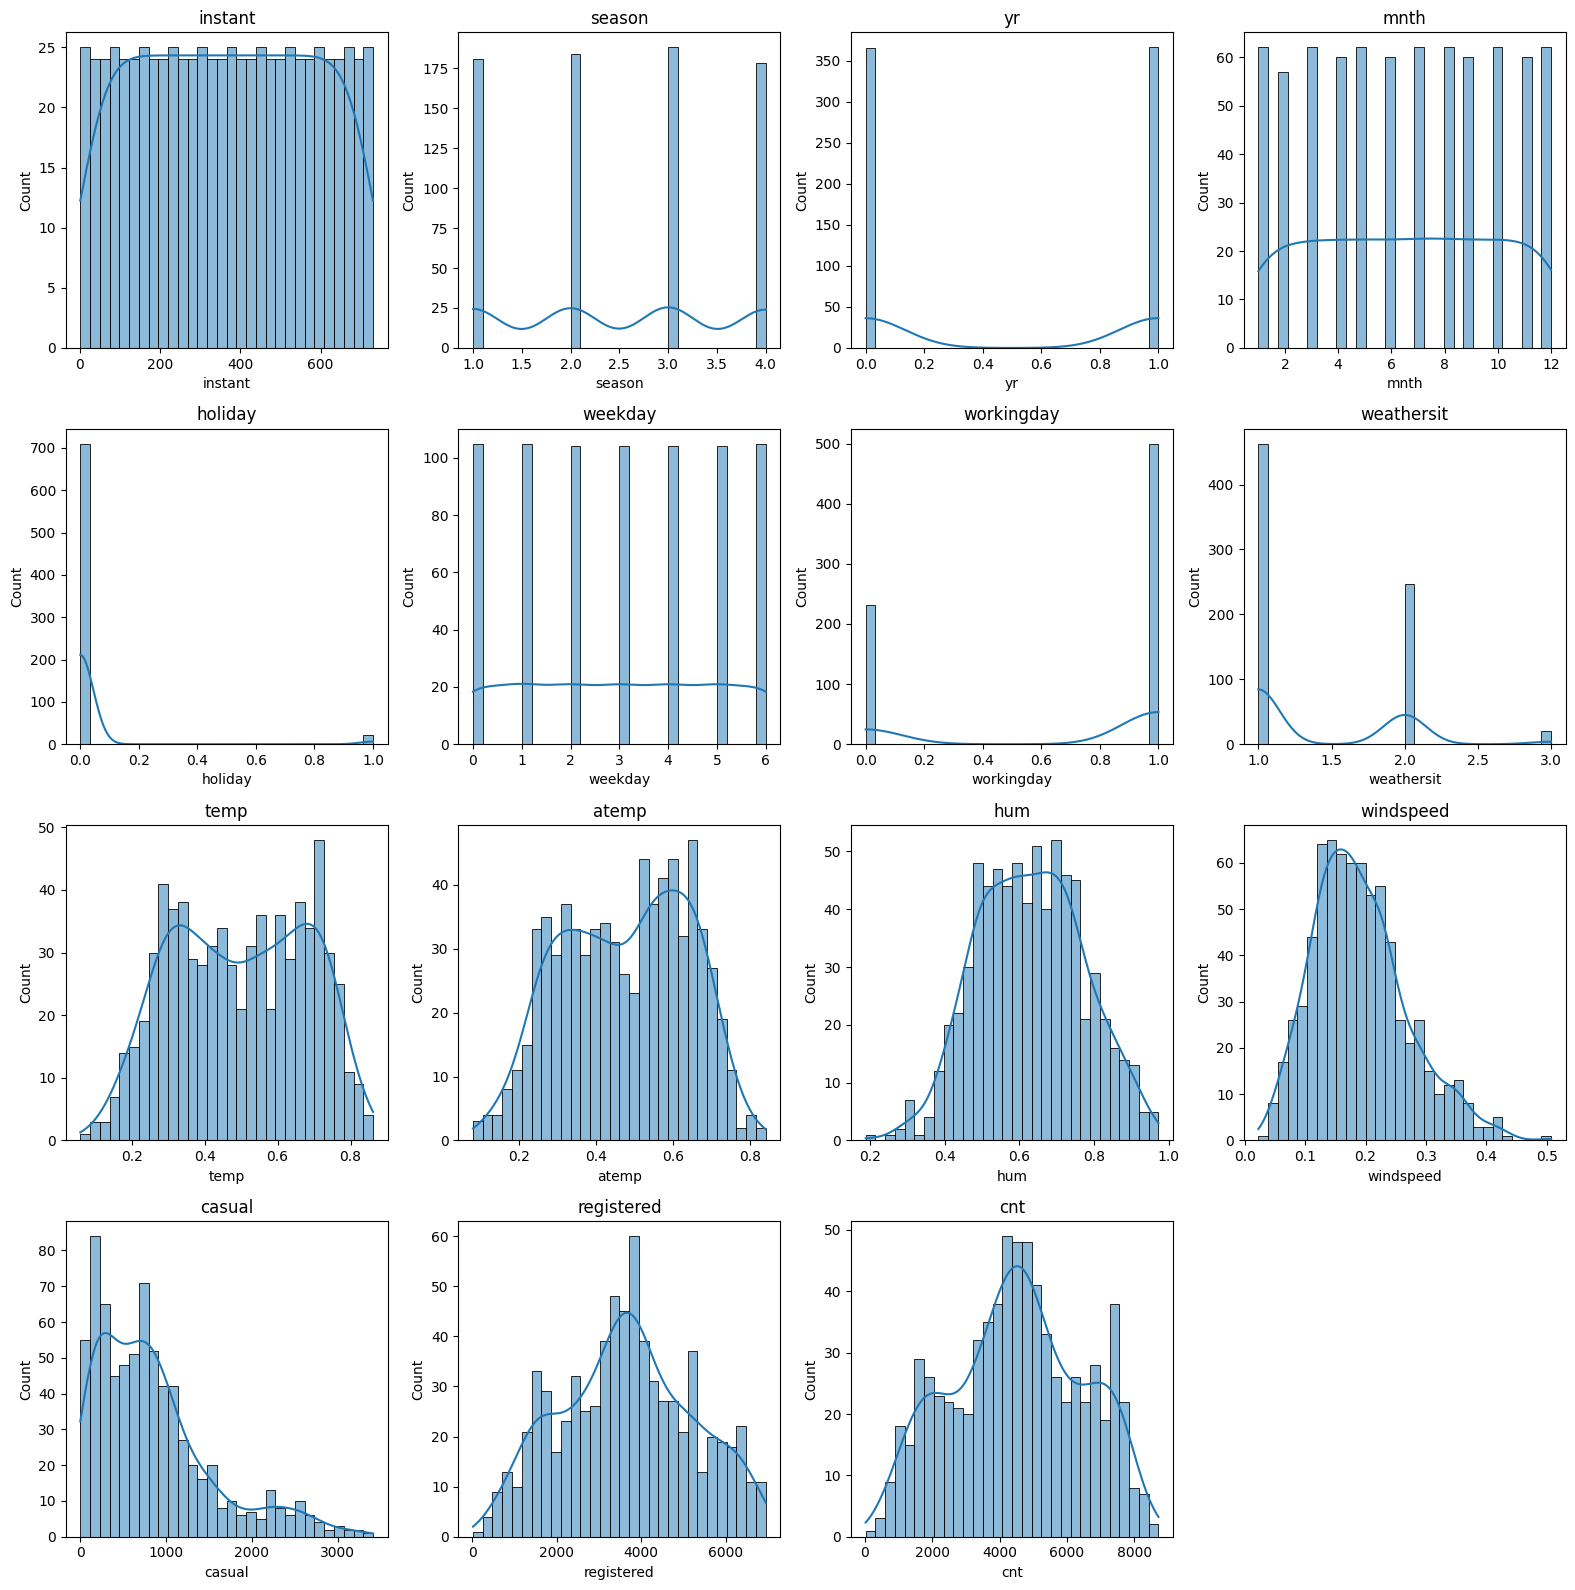

In [25]:
#melihat distribusi data menggunakan histogram
#mengambil data numerik
num_cols = day_df.select_dtypes(include=["number"]).columns

#Membuat histogram data numerik
num_features = day_df.select_dtypes(include=[np.number]).columns
n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))

for i, column in enumerate(num_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(day_df[column], bins=30, kde=True)
    plt.title(column)

plt.tight_layout()
plt.show()


**insight**

1. Tidak terdapat data yang berbentuk loncewng karena data terlalu bervariasi sehingga tidak membentuk distribusi normal. beberapa data, seperti windspeen dan casual memiliki plot positive skewed. Selain itu ada yang negativew skewed yaitu hum.

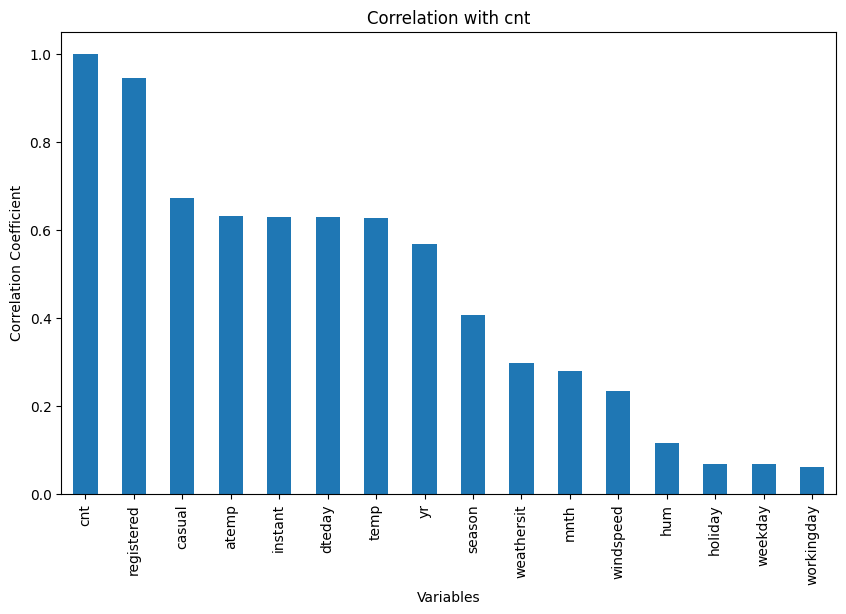

In [22]:
#Menghitung korelasi dengan variable target (cnt)
target_corr = day_df.corr()['cnt']

# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with cnt')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

**insight:**
variable yang memiliki korelasi tertinggi dengan variabel target(cnt) yaitu variable registered dan casual. Hal ini menunjukkan bahwa registered dan casual berpengaruh dalam fluktuasi nilai cnt

### Explore hour_df

In [24]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

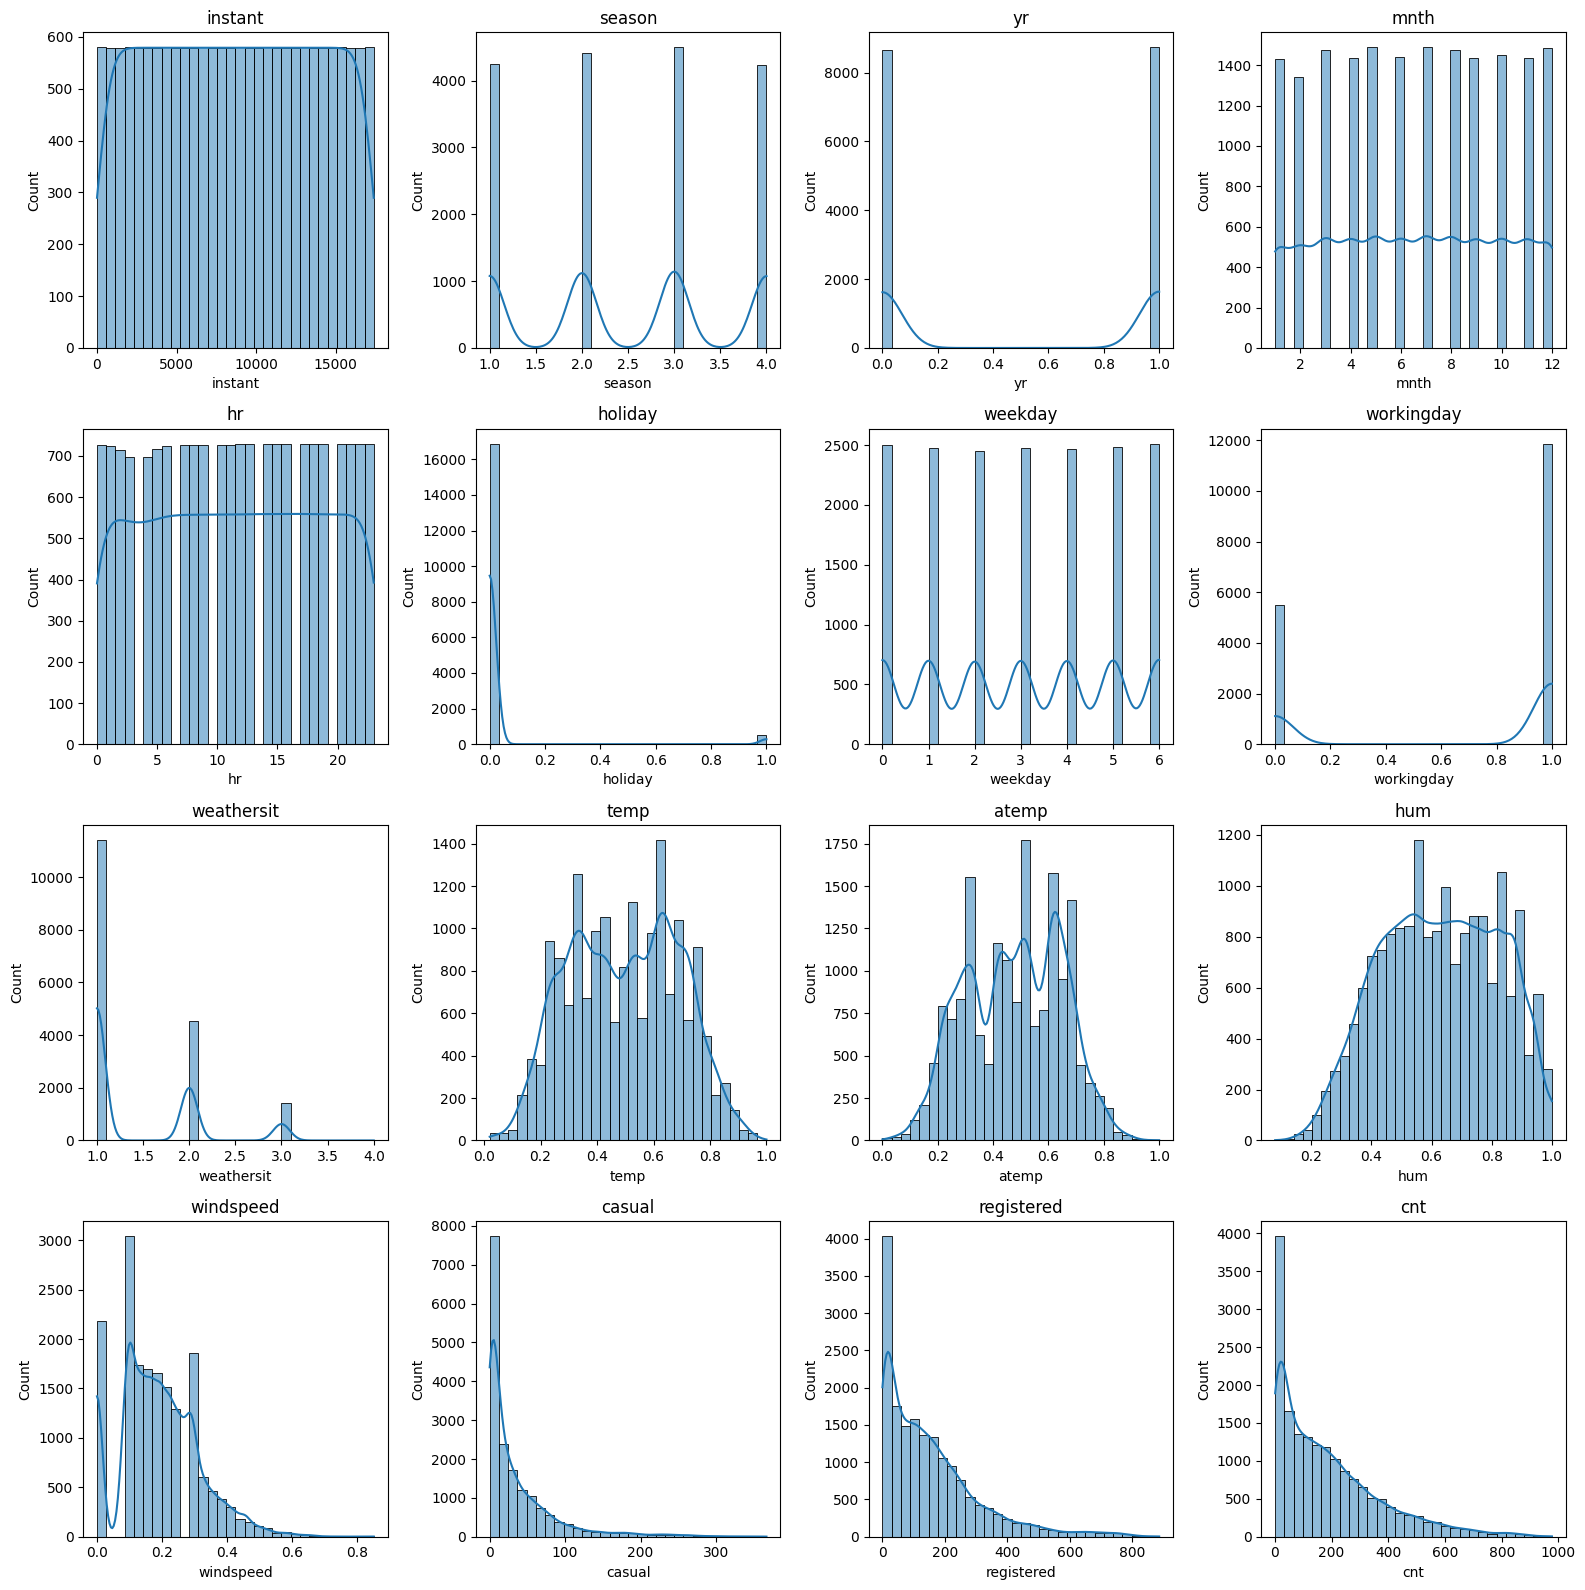

In [26]:
#melihat distribusi data menggunakan histogram
#mengambil data numerik
num_cols = hour_df.select_dtypes(include=["number"]).columns

#Membuat histogram data numerik
num_features = hour_df.select_dtypes(include=[np.number]).columns
n_cols = 4
n_rows = (len(num_features) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 4 * n_rows))

for i, column in enumerate(num_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(hour_df[column], bins=30, kde=True)
    plt.title(column)

plt.tight_layout()
plt.show()


**insight:**
berdasarkan histogram, tidak terdapat data yang terdistribusi normal yang disebabkan oleh banyaknya variasi data. Selain itu ada bebrrapa variabel yang positive skewed, yaitu windspeed, casual, registered, dan cnt.

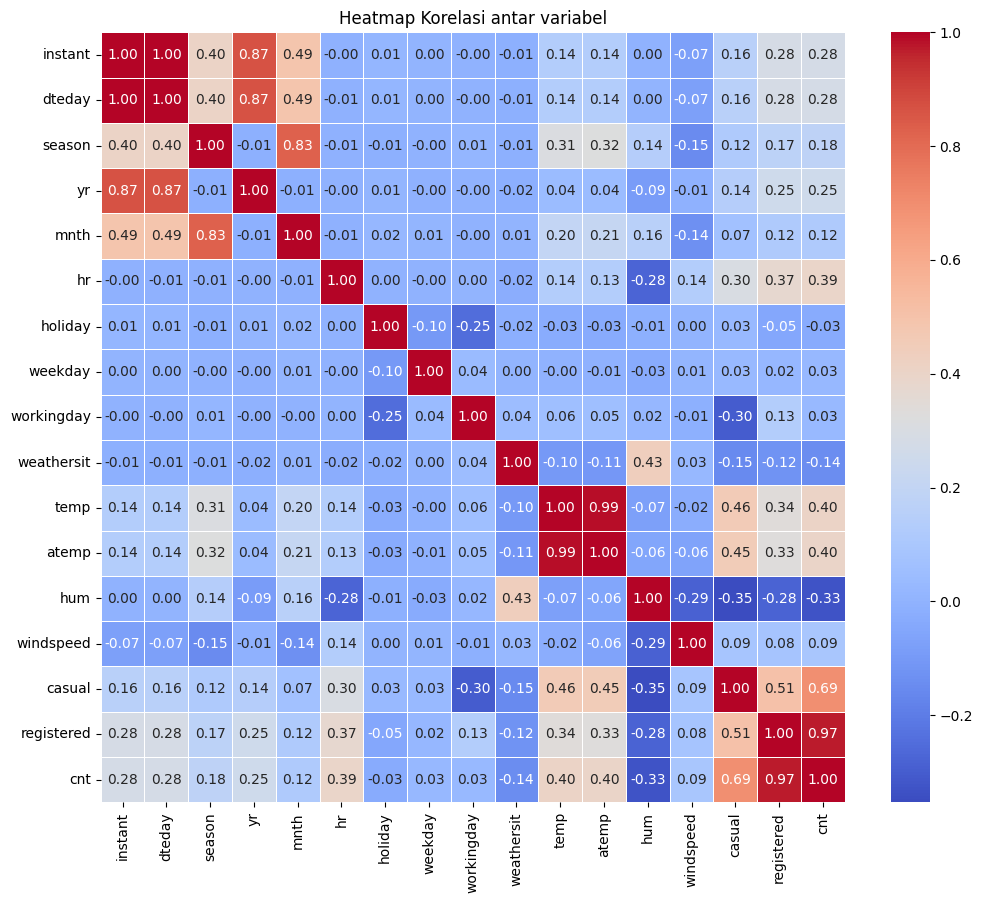

In [27]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = hour_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi antar variabel')
plt.show()

**insight:**
Berdasarkan heatmap tersebut, terdapat korelasi tertinggi antar variable yaitu variabel registered dengan cnt yang menunjukkan bahwa banyaknya pengguna yang melakukan peminjaman member berpengaruh terhadap total pengguna, begitupun sebaliknya. Selain itu, suhu aktual yang diukur juga berpengaruh terhadap suhu yang dirasakan oleh manusia begitupun sebaliknya.




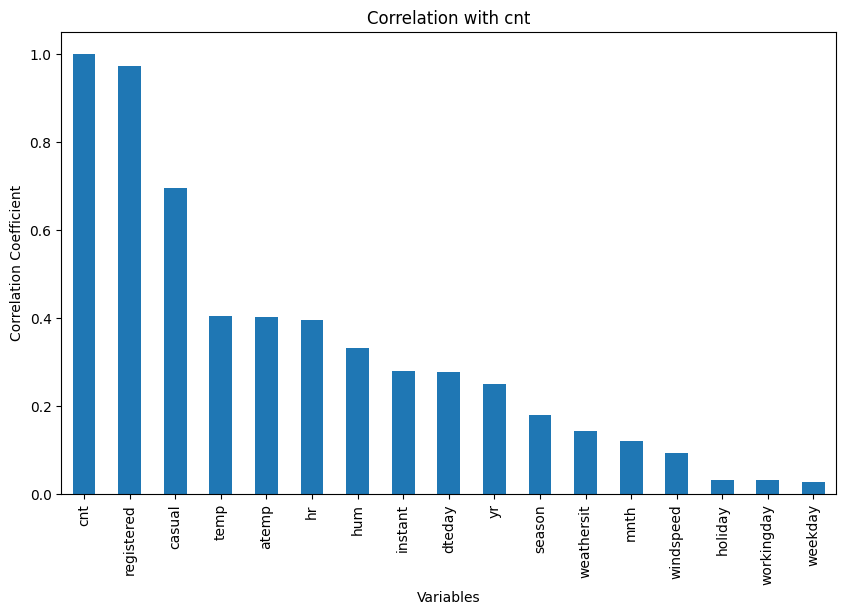

In [28]:
#Menghitung korelasi dengan variable target (cnt)
target_corr = hour_df.corr()['cnt']

# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with cnt')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

**insight:**
variable yang memiliki korelasi tertinggi dengan variabel target(cnt) yaitu variable registered dan casual. Hal ini menunjukkan bahwa registered dan casual berpengaruh dalam fluktuasi nilai cnt

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Selama periode 2011-2012, bagaimana perubahan rata-rata peminjaman sepeda per bulan, rata-rata menurut musim dan kondisi cuaca untuk menentukan periode prioritas penambahan kapasitas operasional?

In [34]:
monthly_line_chart = alt.Chart(monthly_trend).mark_line(point=True, strokeWidth=3).encode(
    x=alt.X('month_name:N', sort=MONTH_ORDER, title='Bulan'),
    y=alt.Y('average_rentals:Q', title='Rata-Rata Peminjaman'),
    color=alt.Color('year_label:N', title='Tahun', scale=alt.Scale(range=[COLOR_PRIMARY, COLOR_ACCENT]))
).properties(
    title='Rata-Rata Peminjaman Harian per Bulan (2011 vs 2012)',
    width=CHART_WIDTH,
    height=CHART_HEIGHT
)

monthly_line_chart

alt.Chart(...)

In [35]:
season_chart = alt.Chart(seasonal_avg).mark_bar(cornerRadiusTopRight=6, cornerRadiusBottomRight=6).encode(
    y=alt.Y('season_label:N', sort=SEASON_ORDER, title='Musim'),
    x=alt.X('average_rentals:Q', title='Rata-Rata Peminjaman'),
    color=alt.Color('season_label:N', scale=alt.Scale(domain=SEASON_ORDER, range=PALETTE), legend=None)
).properties(
    title='Rata-Rata Peminjaman Harian Berdasarkan Musim',
    width=CHART_WIDTH,
    height=CHART_HEIGHT
)

season_chart

alt.Chart(...)

In [36]:
weather_chart = alt.Chart(weather_avg).mark_bar(cornerRadiusTopLeft=6, cornerRadiusTopRight=6).encode(
    x=alt.X('weather_label:N', sort=WEATHER_ORDER, title='Kondisi Cuaca'),
    y=alt.Y('average_rentals:Q', title='Rata-Rata Peminjaman'),
    color=alt.Color(
        'weather_label:N',
        scale=alt.Scale(domain=['Clear', 'Mist', 'Light Rain/Snow'], range=[COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT]),
        legend=None
    )
).properties(
    title='Rata-Rata Peminjaman Harian Berdasarkan Kondisi Cuaca',
    width=CHART_WIDTH,
    height=CHART_HEIGHT
)

weather_chart

alt.Chart(...)

**Insight:** (Opsional)

- Pada tahun 2011, terjadi fluktuasi peminjaman harian dari bulan januari hingga juli sebelum pada akhirnya meningkat pada bulan September (Peminjaman tertinggi). Kemudian terjadi penurunan secara perlahan hingga bulan desember.
- Pada tahun 2012, terjadi peningkatan di bulan januari hingga juni (peminjaman tertinggi), kemudian menurun secara perlahan hingga bulan desember
- Peminjaman sepeda tertinggi terjadi pada musim gugur, diikuti oleh musim panas, musim dingin, dan yang terendah yaitu musim panas.
-Peminjaman sepeda tertinggi terjadi pada kondisi cuaca cerah, diikuti oleh berkabut, serta hujan dan bersalju ringan



### Pertanyaan 2:

Selama periode 2011-2012, kapan jam puncak peminjaman pada hari kerja dan akhir pekan, serta bagaimana perbedaan pola pengguna casual dan registered untuk menyusun strategi redistribusi sepeda dan promosi yang lebih tepat waktu?

In [39]:
hourly_day_type_long = (
    df_hour_clean.groupby(['hr', 'day_type'])['cnt']
    .mean()
    .reset_index(name='average_rentals')
)

hourly_day_type_chart = alt.Chart(hourly_day_type_long).mark_line(point=True, strokeWidth=3).encode(
    x=alt.X('hr:O', title='Jam'),
    y=alt.Y('average_rentals:Q', title='Rata-Rata Peminjaman'),
    color=alt.Color('day_type:N', title='Tipe Hari', scale=alt.Scale(range=[COLOR_PRIMARY, COLOR_SECONDARY]))
).properties(
    title='Pola Peminjaman per Jam pada Hari Kerja vs Akhir Pekan/Hari Libur',
    width=CHART_WIDTH,
    height=CHART_HEIGHT
)

hourly_day_type_chart

alt.Chart(...)

In [40]:
hourly_rider_long = (
    df_hour_clean.groupby('hr')[['casual', 'registered']]
    .mean()
    .reset_index()
    .melt(id_vars='hr', var_name='user_type', value_name='average_rentals')
)

rider_type_chart = alt.Chart(hourly_rider_long).mark_line(point=True, strokeWidth=3).encode(
    x=alt.X('hr:O', title='Jam'),
    y=alt.Y('average_rentals:Q', title='Rata-Rata Peminjaman'),
    color=alt.Color(
        'user_type:N',
        title='Tipe Pengguna',
        scale=alt.Scale(domain=['casual', 'registered'], range=[COLOR_ACCENT, COLOR_PRIMARY])
    )
).properties(
    title='Perbandingan Pola Jam Pengguna Casual dan Registered',
    width=CHART_WIDTH,
    height=CHART_HEIGHT
)

rider_type_chart

alt.Chart(...)

**Insight:** (Opsional)
- Pola pengguna casual memiliki frekuensi peminjaman rendah dan di jam yang tidak pasti - Pada working day, pola peminjaman terjadi mulai di jam 12 malam yang diasumsikan peminjaman yang dilakukan oleh orang pulang lembur lalu menurun hingga jam 5. Setelah itu, terjadi kenaikan mulai jam 5 hingga jam 8 pagi yang diasumsikan peminjaman oleh orang berangkat kerja. Kemudian pola peminjaman berfluktuasi hingga terjadi kenaikan pada jam 3 hingga 5 sore yang diasumsikan peminjaman dilakukan oleh orang pulang kerja. Kemudian peminjaman menurun hingga jam 11 malam. Puncak peminjaman tertinggi terjadi di jam 4 sore
- Pada weekend, pola peminjaman terjadi mulai jam 12 malam yang menurun  hingga jam 6. Peningkatan terjadi di jam 6 hingga jam 12 siang lalu konstan dan menurun di jam 4 sore hingga 11 malam. Puncak peminjaman tertinggi terjadi di jam 12 siang
sehingga tidak terjadi fluktuasi. namun, pengguna registered memiliki frekuensi peminjaman lebih banyak dengan titik puncak peminjaman tertinggi di jam 8 pagi yang diasumsikan sebagai waktu berangkat kerja dan di jam 5 sore yang diasumsikan waktu pulang kerja. Berdasarkan hal yersebut juga dapat diasumsikan peminjaman dilakukan oleh peekerja yang ingin berangkat/pulang kerja    


## Analisis Lanjutan (Opsional)

In [41]:
season_tier_share = pd.crosstab(
    df_day_clean['season_label'],
    df_day_clean['demand_tier'],
    normalize='index'
)
weather_tier_share = pd.crosstab(
    df_day_clean['weather_label'],
    df_day_clean['demand_tier'],
    normalize='index'
)

display((season_tier_share * 100).round(1))
display((weather_tier_share * 100).round(1))

season_tier_long = (season_tier_share * 100).reset_index().melt(
    id_vars='season_label',
    var_name='demand_tier',
    value_name='share_pct'
)

season_tier_chart = alt.Chart(season_tier_long).mark_rect().encode(
    x=alt.X('demand_tier:N', sort=['Low', 'Medium', 'High', 'Very High'], title='Tier Permintaan'),
    y=alt.Y('season_label:N', sort=SEASON_ORDER, title='Musim'),
    color=alt.Color('share_pct:Q', title='Persentase', scale=alt.Scale(scheme='oranges')),
    tooltip=['season_label:N', 'demand_tier:N', alt.Tooltip('share_pct:Q', format='.1f')]
).properties(
    title='Persentase Tier Permintaan Harian pada Setiap Musim',
    width=520,
    height=260
)

season_tier_chart

demand_tier,Low,Medium,High,Very High
season_label,,,,
Spring,67.4,23.8,6.1,2.8
Summer,15.2,23.4,27.7,33.7
Fall,2.1,21.8,34.0,42.0
Winter,16.3,31.5,31.5,20.8


demand_tier,Low,Medium,High,Very High
weather_label,,,,
Clear,18.4,23.3,27.9,30.5
Mist,32.0,30.0,21.1,17.0
Light Rain/Snow,90.5,4.8,4.8,0.0


alt.Chart(...)

- Analisis binning menunjukkan 42,0% hari pada musim Fall berada di tier Very High, sedangkan 67,4% hari pada Spring masuk tier Low.
- Pada cuaca Light Rain/Snow, sekitar 90,5% hari berada di tier Low, sehingga cuaca buruk sangat layak diperlakukan sebagai sinyal penyesuaian kapasitas dan komunikasi ke pengguna.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Tren penyewaan dipengaruhi oleh bulan, musim, dan cuaca. Puncak terjadi pada periode tertentu (2011: September, 2012: Juni), dengan penyewaan tertinggi pada musim gugur dan saat cuaca cerah.

- **Conclusion pertanyaan 2:** Hari kerja memiliki dua puncak (pagi & sore) jam produktif pekerja, sedangkan akhir pekan memuncak di siang hari (rekreasi). Pengguna registered lebih dominan dan konsisten dibanding casual.


**Rekomendasi Action Item:**
- Menambah jumlah sepeda pada jam sibuk (07.00–09.00 dan 16.00–18.00) serta musim dengan permintaan tinggi
- Mengoptimalkan strategi berbeda untuk weekday (commuting) dan weekend (rekreasi)
- Meningkatkan retensi pengguna registered melalui program loyalitas
- Menarik pengguna casual dengan promo khusus akhir pekan atau event
- Mengintegrasikan analisis cuaca dan tren historis untuk perencanaan operasional
